# CREMA-D: Layer-Wise Frozen Probing for Speech Emotion Recognition

**Final Project -- CSCI 535**

Run frozen layer-wise probing on the CREMA-D dataset across all 6 speech transformers in our family. CREMA-D is a controlled benchmark where 91 actors speak the same 12 sentences across 6 emotions, so the linguistic content is held constant. Any accuracy difference between emotions has to come from acoustic delivery, not from the words. This makes CREMA-D the cleanest possible test of our linguistic-agnostic claim.

**Dataset** -- 7,442 audio clips, 91 actors, 6 emotions (ANG, DIS, FEA, HAP, NEU, SAD)  
**Models** -- wav2vec2, HuBERT, Whisper, WavLM, MERT, w2v-BERT (frozen)  
**Probing** -- LogisticRegression(max_iter=1000, lbfgs, C=1.0) + StandardScaler + 5-fold StratifiedKFold

Pipeline matches Nima's frozen probing setup in `train.py` so the CREMA-D results are directly comparable with the existing 7-dataset numbers.

In [1]:
import os, re, glob, json, gc, traceback
from datetime import datetime
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoConfig, AutoFeatureExtractor
import transformers.modeling_utils
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from scipy.io import wavfile
from scipy.signal import resample
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

if hasattr(transformers.modeling_utils, 'check_torch_load_is_safe'):
    transformers.modeling_utils.check_torch_load_is_safe = lambda: None

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Configuration & Paths

In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================
PROJECT_ROOT = '/Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final'
DATA_DIR = os.path.join(PROJECT_ROOT, 'my_code', 'data')
CREMAD_DIR = os.path.join(DATA_DIR, 'CREMA-D', 'AudioWAV')

RESULTS_DIR = os.path.join(PROJECT_ROOT, 'my_code', 'results', 'cremad')
EMBEDDINGS_DIR = os.path.join(RESULTS_DIR, 'embeddings')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

# ============================================================
# MODELS -- HuggingFace checkpoints, same family as the rest of the paper
# ============================================================
MODEL_CONFIGS = {
    'wav2vec2': 'facebook/wav2vec2-large-960h',
    'HuBERT':   'facebook/hubert-large-ll60k',
    'Whisper':  'openai/whisper-medium',
    'WavLM':    'microsoft/wavlm-large',
    'MERT':     'm-a-p/MERT-v1-330M',
    'w2v-BERT': 'facebook/w2v-bert-2.0',
}

# ============================================================
# CREMA-D EMOTION MAPPING (filename code -> canonical label)
# ============================================================
CREMAD_EMOTION_MAP = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad',
}

# ============================================================
# PROBING + EXTRACTION HYPERPARAMETERS
# ============================================================
SAMPLE_RATE = 16000  # baseline rate for wav2vec2/HuBERT/Whisper/WavLM/w2v-BERT
MERT_SAMPLE_RATE = 24000  # MERT was pretrained at 24kHz, requires resampling
N_SPLITS = 5
RANDOM_STATE = 42

# Per-model batch size. Whisper pads every clip to 30s = 480k samples (heaviest);
# MERT has a beefy frontend; the wav2vec2-family handles 8 fine on M4 Max.
BATCH_SIZE_PER_MODEL = {
    'wav2vec2': 8,
    'HuBERT':   8,
    'Whisper':  2,
    'WavLM':    8,
    'MERT':     4,
    'w2v-BERT': 4,
}

# Plot style (matching layer_mixer / lora notebooks)
PLOT_STYLE = {
    'acc_color':   '#2196F3',
    'f1_color':    '#FF5722',
    'figsize':     (10, 5),
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_fontsize':  10,
    'legend_fontsize': 11,
    'grid_alpha':  0.3,
    'dpi':         300,
}
LAYER_LABELS = ['CNN'] + [str(i) for i in range(1, 25)]

print(f"Models ({len(MODEL_CONFIGS)}):")
for k, v in MODEL_CONFIGS.items():
    bs = BATCH_SIZE_PER_MODEL.get(k, 4)
    print(f"  {k:<10} -> {v}  (batch_size={bs})")
print(f"\nCREMA-D emotion mapping: {CREMAD_EMOTION_MAP}")
print(f"\nResults directory: {RESULTS_DIR}")

Models (6):
  wav2vec2   -> facebook/wav2vec2-large-960h  (batch_size=8)
  HuBERT     -> facebook/hubert-large-ll60k  (batch_size=8)
  Whisper    -> openai/whisper-medium  (batch_size=2)
  WavLM      -> microsoft/wavlm-large  (batch_size=8)
  MERT       -> m-a-p/MERT-v1-330M  (batch_size=4)
  w2v-BERT   -> facebook/w2v-bert-2.0  (batch_size=4)

CREMA-D emotion mapping: {'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fear', 'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad'}

Results directory: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad


## 2. CREMA-D Loader

Filename format is `{ActorID}_{SentenceCode}_{EmotionCode}_{Intensity}.wav` -- e.g. `1001_DFA_ANG_XX.wav`. Emotion code is at position 2 of the filename. The intensity field varies between LO/MD/HI/XX but we treat all utterances equally regardless of intensity. We also retain the actor ID so we can do speaker-level analysis later if needed.

In [3]:
def load_audio_file(filepath, target_sr=16000):
    """Load and normalize a wav file (matching Nima's loader.py)."""
    sr, waveform = wavfile.read(filepath)
    if waveform.dtype == np.int16:
        waveform = waveform.astype(np.float32) / 32768.0
    elif waveform.dtype == np.int32:
        waveform = waveform.astype(np.float32) / 2147483648.0
    else:
        waveform = waveform.astype(np.float32)
        if np.max(np.abs(waveform)) > 1.0:
            waveform = waveform / np.max(np.abs(waveform))
    if len(waveform.shape) > 1 and waveform.shape[1] > 1:
        waveform = np.mean(waveform, axis=1)
    if sr != target_sr:
        num_samples = int(len(waveform) * target_sr / sr)
        waveform = resample(waveform, num_samples)
    return waveform


def load_cremad(path):
    """Load CREMA-D from the AudioWAV directory.

    Returns a list of dicts with file, label, audio, actor, sentence, intensity.
    """
    data = []
    files = sorted(glob.glob(os.path.join(path, '*.wav')))
    for fpath in tqdm(files, desc='CREMA-D'):
        fn = os.path.basename(fpath)
        parts = fn.replace('.wav', '').split('_')
        if len(parts) != 4:
            continue
        actor, sentence, ecode, intensity = parts
        if ecode not in CREMAD_EMOTION_MAP:
            continue
        try:
            audio = load_audio_file(fpath)
            data.append({
                'file': fn,
                'label': CREMAD_EMOTION_MAP[ecode],
                'audio': audio,
                'actor': actor,
                'sentence': sentence,
                'intensity': intensity,
            })
        except Exception:
            pass
    return data


print("CREMA-D loader defined.")

CREMA-D loader defined.


## 3. Load CREMA-D Audio

Walks the AudioWAV folder, parses every filename, decodes the int16 PCM into float32, and keeps a per-sample dict. This takes a couple of minutes on a Mac because of the resample step (CREMA-D is recorded at 16 kHz already so resample is mostly a no-op).

In [4]:
data = load_cremad(CREMAD_DIR)

print(f"\nLoaded {len(data)} samples")

# Quick distribution check
label_counts = pd.Series([d['label'] for d in data]).value_counts()
print(f"\nEmotion distribution:\n{label_counts}")

actor_counts = pd.Series([d['actor'] for d in data]).nunique()
sentence_counts = pd.Series([d['sentence'] for d in data]).nunique()
print(f"\nUnique actors: {actor_counts}")
print(f"Unique sentences: {sentence_counts}")

# Encode labels for probing
le = LabelEncoder()
labels = le.fit_transform([d['label'] for d in data])
print(f"\nEncoded classes: {list(le.classes_)}")

CREMA-D:   0%|          | 0/7442 [00:00<?, ?it/s]

CREMA-D:   5%|▌         | 386/7442 [00:00<00:01, 3850.07it/s]

CREMA-D:  10%|█         | 772/7442 [00:00<00:01, 3485.43it/s]

CREMA-D:  16%|█▌        | 1171/7442 [00:00<00:01, 3701.28it/s]

CREMA-D:  21%|██▏       | 1599/7442 [00:00<00:01, 3921.26it/s]

...

CREMA-D:  85%|████████▍ | 6309/7442 [00:01<00:00, 4196.24it/s]

CREMA-D:  90%|█████████ | 6730/7442 [00:01<00:00, 4195.48it/s]

CREMA-D:  96%|█████████▌| 7150/7442 [00:01<00:00, 4146.26it/s]

CREMA-D: 100%|██████████| 7442/7442 [00:01<00:00, 4077.83it/s]


Loaded 7442 samples

Emotion distribution:
angry      1271
disgust    1271
fear       1271
happy      1271
sad        1271
neutral    1087
Name: count, dtype: int64

Unique actors: 91
Unique sentences: 12

Encoded classes: [np.str_('angry'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


## 4. Hidden State Extraction

For each frozen model, run every audio file through and pull the hidden state at every layer. Mean-pool over time to get a fixed-size vector per layer. Save as `(num_samples, 25, hidden_dim)` .npy so we can re-probe without re-extracting.

Two model-specific quirks handled here:
- **Whisper** needs `padding='max_length'` on its feature extractor so every clip is padded to 3000 mel frames (30s). Default `padding=True` only pads to longest-in-batch, which causes Whisper to error.
- **MERT** was pretrained at 24kHz, so we resample our 16kHz audio to 24kHz before passing it to MERT's feature extractor.

In [5]:
class CREMADAudioDataset(Dataset):
    """Wraps the loaded audio arrays for a DataLoader."""
    def __init__(self, audios):
        self.audios = audios
    def __len__(self):
        return len(self.audios)
    def __getitem__(self, idx):
        return self.audios[idx]


def collate_pad(batch):
    """Pad variable-length audio to the longest in the batch."""
    max_len = max(a.shape[0] for a in batch)
    padded = torch.zeros(len(batch), max_len)
    for i, a in enumerate(batch):
        padded[i, :a.shape[0]] = torch.FloatTensor(a)
    return padded


def extract_hidden_states(model_key, hf_name, audio_list, batch_size=4):
    """Extract mean-pooled hidden states from every layer for a list of audios.

    Returns a numpy array of shape (num_samples, num_layers, hidden_dim).
    """
    is_whisper = 'whisper' in hf_name.lower()
    is_mert = 'MERT' in hf_name

    config = AutoConfig.from_pretrained(hf_name, trust_remote_code=True)
    config.output_hidden_states = True
    safe = 'MERT' not in hf_name
    model = AutoModel.from_pretrained(
        hf_name, config=config, use_safetensors=safe, trust_remote_code=True
    ).to(DEVICE)
    model.eval()
    fe = AutoFeatureExtractor.from_pretrained(hf_name, trust_remote_code=True)

    # MERT needs 24kHz audio; resample once up-front so the dataset/loader is fast
    if is_mert:
        target_sr = MERT_SAMPLE_RATE
        audio_list_used = [resample(a, int(len(a) * MERT_SAMPLE_RATE / SAMPLE_RATE)) for a in audio_list]
    else:
        target_sr = SAMPLE_RATE
        audio_list_used = audio_list

    ds = CREMADAudioDataset(audio_list_used)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate_pad)

    all_layer_means = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'{model_key}'):
            wav_list = [w.cpu().numpy() for w in batch]

            # Whisper requires padding='max_length' (pads to 3000 mel frames = 30s);
            # padding=True only pads to longest-in-batch which Whisper rejects.
            if is_whisper:
                inputs = fe(wav_list, sampling_rate=target_sr, return_tensors='pt', padding='max_length')
            else:
                inputs = fe(wav_list, sampling_rate=target_sr, return_tensors='pt', padding=True)

            if is_whisper and 'input_features' in inputs:
                model_inputs = {'input_features': inputs['input_features'].to(DEVICE)}
                outputs = model.encoder(**model_inputs)
            elif 'input_values' in inputs:
                model_inputs = {'input_values': inputs['input_values'].to(DEVICE)}
                outputs = model(**model_inputs)
            else:
                model_inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                outputs = model(**model_inputs)

            hidden_states = outputs.hidden_states
            batch_mean = []
            for layer_hs in hidden_states:
                batch_mean.append(layer_hs.mean(dim=1).cpu().numpy())
            batch_stack = np.stack(batch_mean, axis=1)
            all_layer_means.append(batch_stack)

    # Hard cleanup -- transfer the model off GPU before deleting so MPS releases the buffers
    del model
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    elif DEVICE.type == 'mps':
        torch.mps.empty_cache()

    return np.concatenate(all_layer_means, axis=0)


print("extract_hidden_states() defined.")

extract_hidden_states() defined.


## 5. Run Extraction Across All Models

Heaviest cell. For each model, push the 7,442 clips through and save `(7442, 25, hidden_dim)`. Cached so re-running is cheap. Each model uses a per-model batch size, and any failure prints a full traceback so we can debug instead of swallowing the error.

Also writes a persistent log to `cremad_run_log.txt` so failures can be inspected from disk later.

In [6]:
audios = [d['audio'] for d in data]

hidden_states_by_model = {}
failed_extraction = []

# Persistent log so failures can be inspected from disk after the run
LOG_PATH = os.path.join(RESULTS_DIR, 'cremad_run_log.txt')
log_lines = [f"=== CREMA-D extraction started at {datetime.now().isoformat()} ===", ""]

def _flush_log():
    with open(LOG_PATH, 'w') as f:
        f.write('\n'.join(log_lines))

for model_key, hf_name in MODEL_CONFIGS.items():
    save_path = os.path.join(EMBEDDINGS_DIR, f'hidden_states_{model_key}_CREMA-D.npy')
    labels_path = os.path.join(EMBEDDINGS_DIR, f'labels_{model_key}_CREMA-D.npy')

    if os.path.exists(save_path) and os.path.exists(labels_path):
        print(f"CACHED {model_key} -- loading from disk")
        hidden_states_by_model[model_key] = np.load(save_path)
        log_lines.append(f"CACHED {model_key}")
        continue

    bs = BATCH_SIZE_PER_MODEL.get(model_key, 4)
    print(f"\n{'='*60}")
    print(f"Extracting hidden states: {model_key}  batch_size={bs}")
    print(f"{'='*60}")
    log_lines.append(f"\n{'='*60}")
    log_lines.append(f"START {model_key}  batch_size={bs}  at {datetime.now().isoformat()}")

    try:
        hs = extract_hidden_states(model_key, hf_name, audios, batch_size=bs)
        hidden_states_by_model[model_key] = hs
        np.save(save_path, hs)
        np.save(labels_path, labels)
        print(f"  Saved: {save_path}  shape={hs.shape}")
        log_lines.append(f"DONE {model_key}: shape={hs.shape}")
    except Exception as e:
        tb = traceback.format_exc()
        print(f"\n  !!! FAILED {model_key}: {type(e).__name__}: {e}")
        traceback.print_exc()
        failed_extraction.append((model_key, str(e)))
        log_lines.append(f"FAILED {model_key}: {type(e).__name__}: {e}")
        log_lines.append(tb)

    # Hard cleanup between models so the next one starts fresh
    gc.collect()
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    # Flush log after every model so a kernel crash mid-run still leaves a trace
    _flush_log()

log_lines.append(f"\n=== Run finished at {datetime.now().isoformat()} ===")
log_lines.append(f"Extracted: {len(hidden_states_by_model)}/{len(MODEL_CONFIGS)} models")
log_lines.append(f"Failed: {len(failed_extraction)}")
_flush_log()

print(f"\nExtracted hidden states for {len(hidden_states_by_model)}/{len(MODEL_CONFIGS)} models.")
print(f"Log written to: {LOG_PATH}")
if failed_extraction:
    print(f"\nFailures:")
    for k, err in failed_extraction:
        print(f"  {k}: {err[:120]}")

CACHED wav2vec2 -- loading from disk


CACHED HuBERT -- loading from disk


CACHED Whisper -- loading from disk


CACHED WavLM -- loading from disk
CACHED MERT -- loading from disk


CACHED w2v-BERT -- loading from disk



Extracted hidden states for 6/6 models.
Log written to: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/cremad_run_log.txt


## 6. Layer-Wise Probing

Per layer, fit `LogisticRegression(max_iter=1000, lbfgs, C=1.0)` on top of `StandardScaler` features with 5-fold StratifiedKFold. Outputs per-layer accuracy, std, and weighted F1. Same setup as Nima's frozen probe in `train.py`.

In [7]:
def probe_all_layers(hidden_states, labels):
    """Run LogisticRegression probing on each layer.

    Returns DataFrame with Layer, Layer_Num, Accuracy, Std_Accuracy, Weighted_F1.
    """
    num_layers = hidden_states.shape[1]
    results = []
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    for layer_idx in range(num_layers):
        X = hidden_states[:, layer_idx, :]

        fold_accs, fold_f1s = [], []
        for train_idx, val_idx in skf.split(X, labels):
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X[train_idx])
            X_val = scaler.transform(X[val_idx])

            clf = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
            clf.fit(X_train, labels[train_idx])
            preds = clf.predict(X_val)

            fold_accs.append(accuracy_score(labels[val_idx], preds))
            fold_f1s.append(f1_score(labels[val_idx], preds, average='weighted'))

        layer_name = 'CNN' if layer_idx == 0 else str(layer_idx)
        results.append({
            'Layer': layer_name,
            'Layer_Num': layer_idx,
            'Accuracy': np.mean(fold_accs),
            'Std_Accuracy': np.std(fold_accs),
            'Weighted_F1': np.mean(fold_f1s),
        })

    return pd.DataFrame(results)


probing_results = {}
for model_key, hs in hidden_states_by_model.items():
    print(f"Probing {model_key} ({hs.shape})...")
    df = probe_all_layers(hs, labels)
    probing_results[model_key] = df

    csv_path = os.path.join(RESULTS_DIR, f'results_{model_key}_CREMA-D.csv')
    df.to_csv(csv_path, index=False)

    best = df.loc[df['Accuracy'].idxmax()]
    print(f"  Best layer: {best['Layer']} (Acc={best['Accuracy']:.4f}, F1={best['Weighted_F1']:.4f})")
    print(f"  Saved: {csv_path}")

Probing wav2vec2 ((7442, 25, 1024))...


  Best layer: 10 (Acc=0.6935, F1=0.6933)
  Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/results_wav2vec2_CREMA-D.csv
Probing HuBERT ((7442, 25, 1024))...


  Best layer: 13 (Acc=0.7497, F1=0.7496)
  Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/results_HuBERT_CREMA-D.csv
Probing Whisper ((7442, 25, 1024))...


  Best layer: 12 (Acc=0.7476, F1=0.7477)
  Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/results_Whisper_CREMA-D.csv
Probing WavLM ((7442, 25, 1024))...


  Best layer: 14 (Acc=0.7608, F1=0.7610)
  Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/results_WavLM_CREMA-D.csv
Probing MERT ((7442, 25, 1024))...


  Best layer: 9 (Acc=0.6404, F1=0.6402)
  Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/results_MERT_CREMA-D.csv
Probing w2v-BERT ((7442, 25, 1024))...


  Best layer: 17 (Acc=0.7296, F1=0.7298)
  Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/results_w2v-BERT_CREMA-D.csv


## 7. Per-Model Layer-Wise Accuracy Plots

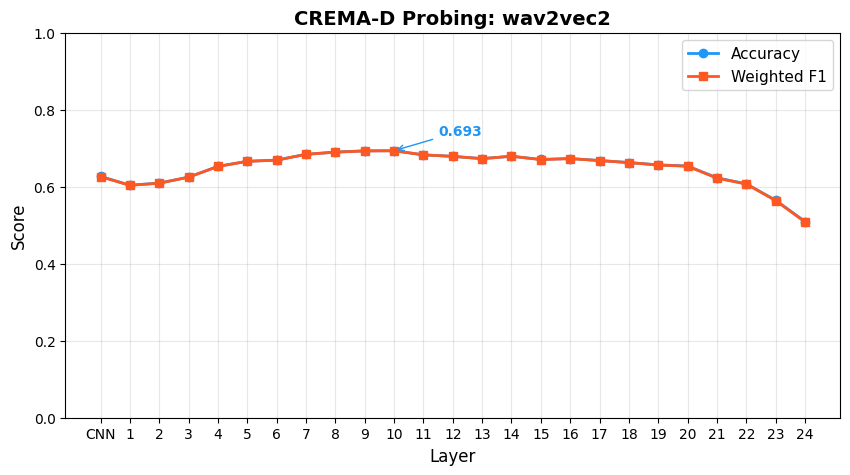

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/probing_wav2vec2_CREMA-D.png


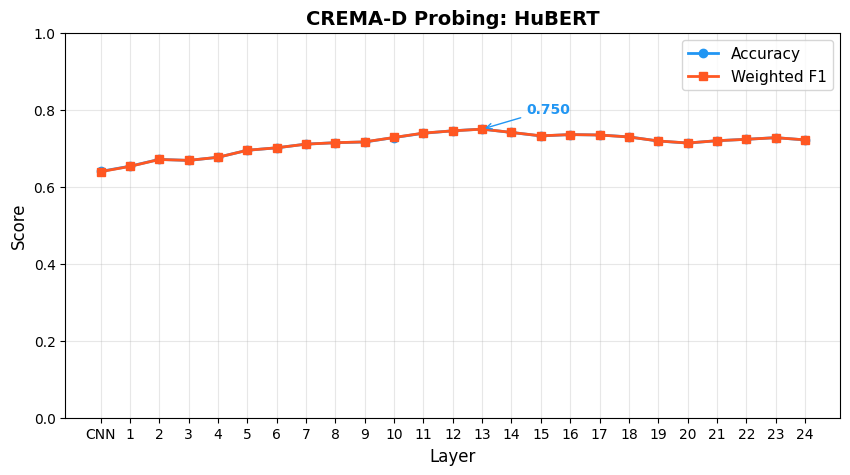

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/probing_HuBERT_CREMA-D.png


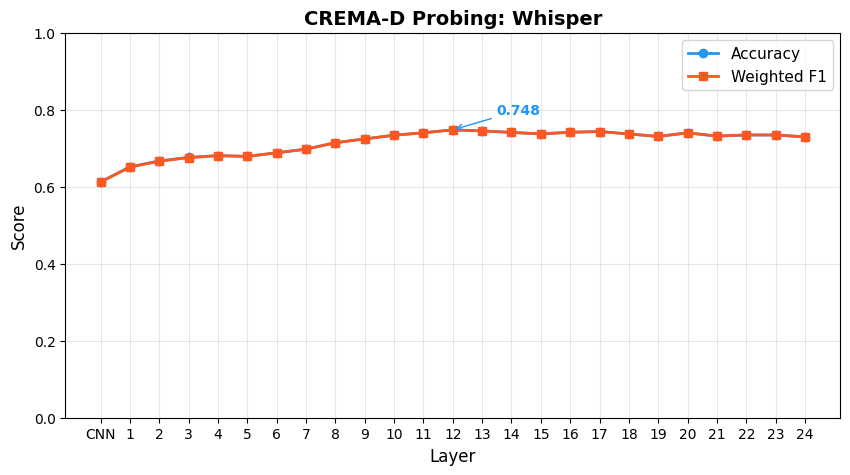

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/probing_Whisper_CREMA-D.png


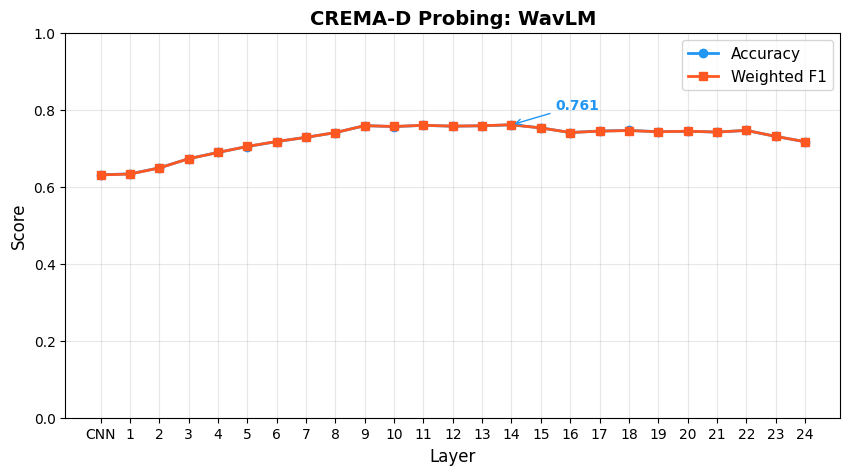

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/probing_WavLM_CREMA-D.png


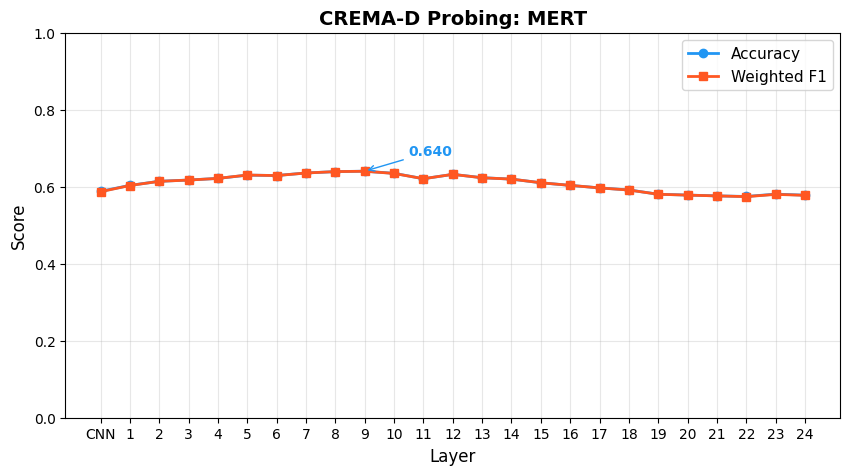

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/probing_MERT_CREMA-D.png


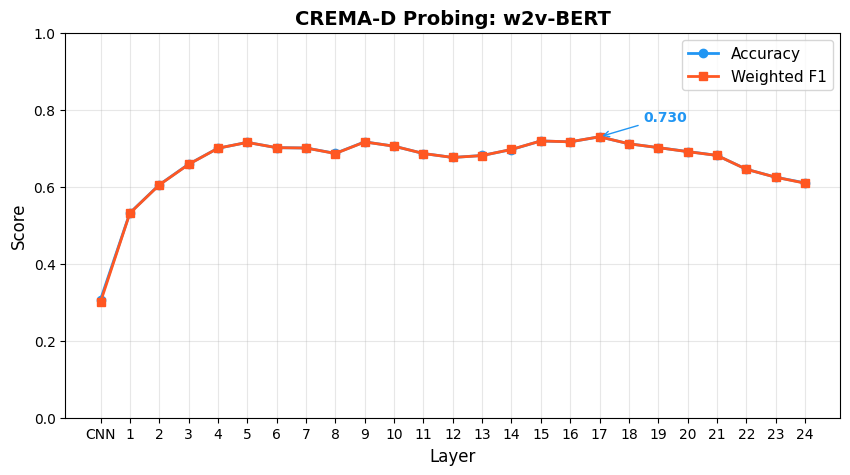

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/probing_w2v-BERT_CREMA-D.png


In [8]:
for model_key, df in probing_results.items():
    fig, ax = plt.subplots(figsize=PLOT_STYLE['figsize'])

    ax.plot(df['Layer_Num'], df['Accuracy'],
            color=PLOT_STYLE['acc_color'], marker='o', linewidth=2,
            label='Accuracy', markersize=6)
    ax.plot(df['Layer_Num'], df['Weighted_F1'],
            color=PLOT_STYLE['f1_color'], marker='s', linewidth=2,
            label='Weighted F1', markersize=6)

    best_idx = df['Accuracy'].idxmax()
    best_acc = df.loc[best_idx, 'Accuracy']
    best_layer = df.loc[best_idx, 'Layer_Num']
    ax.annotate(f'{best_acc:.3f}', xy=(best_layer, best_acc),
                xytext=(best_layer + 1.5, min(best_acc + 0.04, 0.97)),
                fontsize=10, fontweight='bold', color=PLOT_STYLE['acc_color'],
                arrowprops=dict(arrowstyle='->', color=PLOT_STYLE['acc_color']))

    n_layers = len(df)
    ax.set_xticks(range(0, n_layers))
    ax.set_xticklabels([LAYER_LABELS[i] for i in range(n_layers)],
                       fontsize=PLOT_STYLE['tick_fontsize'])
    ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_ylabel('Score', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_ylim([0, 1.0])
    ax.set_title(f'CREMA-D Probing: {model_key}',
                 fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
    ax.legend(fontsize=PLOT_STYLE['legend_fontsize'])
    ax.grid(True, alpha=PLOT_STYLE['grid_alpha'])

    plot_path = os.path.join(RESULTS_DIR, f'probing_{model_key}_CREMA-D.png')
    plt.savefig(plot_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {plot_path}")

## 8. Combined Layer-Wise Comparison Across Models

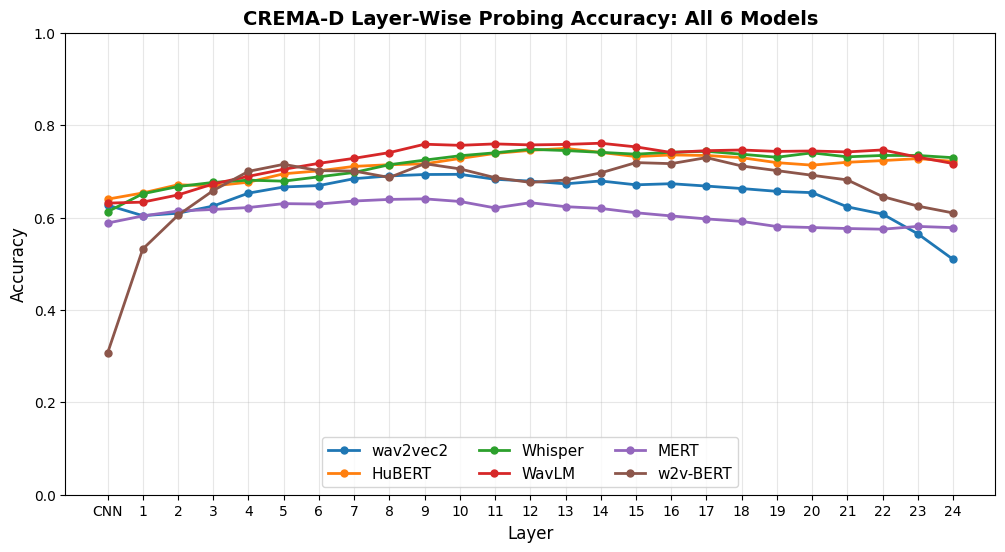

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/cremad_all_models.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

model_palette = {
    'wav2vec2': '#1f77b4',
    'HuBERT':   '#ff7f0e',
    'Whisper':  '#2ca02c',
    'WavLM':    '#d62728',
    'MERT':     '#9467bd',
    'w2v-BERT': '#8c564b',
}

for model_key, df in probing_results.items():
    ax.plot(df['Layer_Num'], df['Accuracy'],
            color=model_palette.get(model_key, 'gray'),
            marker='o', linewidth=2, label=model_key, markersize=5)

ax.set_xticks(range(0, 25))
ax.set_xticklabels(LAYER_LABELS, fontsize=PLOT_STYLE['tick_fontsize'], rotation=0)
ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Accuracy', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylim([0, 1.0])
ax.set_title('CREMA-D Layer-Wise Probing Accuracy: All 6 Models',
             fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(fontsize=PLOT_STYLE['legend_fontsize'], loc='lower center', ncol=3)
ax.grid(True, alpha=PLOT_STYLE['grid_alpha'])

combined_path = os.path.join(RESULTS_DIR, 'cremad_all_models.png')
plt.savefig(combined_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {combined_path}")

## 9. Heatmap: Models vs Layers Accuracy

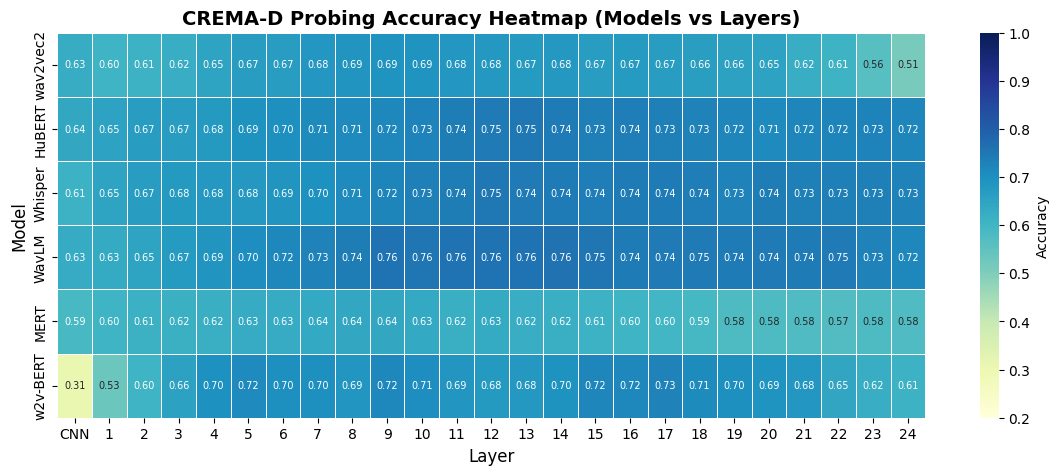

Saved: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/cremad/cremad_heatmap.png


In [10]:
heatmap_data = []
model_order = list(probing_results.keys())
for model_key in model_order:
    df = probing_results[model_key]
    heatmap_data.append(df['Accuracy'].values)
heatmap_data = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, ax=ax,
            xticklabels=LAYER_LABELS[:heatmap_data.shape[1]],
            yticklabels=model_order,
            cmap='YlGnBu', vmin=0.2, vmax=1.0,
            cbar_kws={'label': 'Accuracy'},
            linewidths=0.4, annot=True, fmt='.2f', annot_kws={'size': 7})
ax.set_title('CREMA-D Probing Accuracy Heatmap (Models vs Layers)',
             fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Model', fontsize=PLOT_STYLE['label_fontsize'])

heatmap_path = os.path.join(RESULTS_DIR, 'cremad_heatmap.png')
plt.savefig(heatmap_path, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {heatmap_path}")

## 10. Summary Table & Save Results

In [ ]:
summary_rows = []
for model_key, df in probing_results.items():
    best = df.loc[df['Accuracy'].idxmax()]
    cnn_row = df.iloc[0]
    last_row = df.iloc[-1]
    summary_rows.append({
        'Model': model_key,
        'Best_Layer': best['Layer'],
        'Best_Acc': float(best['Accuracy']),
        'Best_F1':  float(best['Weighted_F1']),
        'CNN_Acc':  float(cnn_row['Accuracy']),
        'Last_Layer_Acc': float(last_row['Accuracy']),
        'Mean_Acc': float(df['Accuracy'].mean()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, 'cremad_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(summary_df.to_string(index=False))
print(f"\nSaved: {summary_path}")

# List all outputs
print(f"\n{'='*60}")
print(f"All outputs in: {RESULTS_DIR}")
print(f"{'='*60}")
for f in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"  {f:<50} {size_mb:>8.1f} MB")

## 11. Per-Sentence and Per-Actor Sanity Checks

In [ ]:
best_model = summary_df.loc[summary_df['Best_Acc'].idxmax(), 'Model']
best_layer_str = summary_df.loc[summary_df['Best_Acc'].idxmax(), 'Best_Layer']
best_layer_idx = 0 if best_layer_str == 'CNN' else int(best_layer_str)
print(f"Per-sentence and per-actor sanity check using {best_model}, Layer {best_layer_str}")

X_best = hidden_states_by_model[best_model][:, best_layer_idx, :]
scaler = StandardScaler()
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

preds_full = np.zeros(len(labels), dtype=int)
for train_idx, val_idx in skf.split(X_best, labels):
    Xt = scaler.fit_transform(X_best[train_idx])
    Xv = scaler.transform(X_best[val_idx])
    clf = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
    clf.fit(Xt, labels[train_idx])
    preds_full[val_idx] = clf.predict(Xv)

df_meta = pd.DataFrame({
    'actor':    [d['actor'] for d in data],
    'sentence': [d['sentence'] for d in data],
    'label':    labels,
    'pred':     preds_full,
})
df_meta['correct'] = (df_meta['label'] == df_meta['pred']).astype(int)

per_sentence = df_meta.groupby('sentence')['correct'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy'})
per_actor = df_meta.groupby('actor')['correct'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy'})

print(f"\nPer-sentence accuracy (top + bottom):")
print(per_sentence.sort_values('accuracy', ascending=False).head(6).to_string())
print("...")
print(per_sentence.sort_values('accuracy', ascending=False).tail(3).to_string())

print(f"\nPer-actor accuracy stats: mean={per_actor['accuracy'].mean():.4f}, "
      f"std={per_actor['accuracy'].std():.4f}, "
      f"min={per_actor['accuracy'].min():.4f}, max={per_actor['accuracy'].max():.4f}")

per_sentence.to_csv(os.path.join(RESULTS_DIR, 'cremad_per_sentence.csv'))
per_actor.to_csv(os.path.join(RESULTS_DIR, 'cremad_per_actor.csv'))
print(f"\nSaved per-sentence and per-actor breakdowns.")